# EDA Report — Inventory Optimization

This notebook performs exploratory data analysis (EDA) on the project's datasets and saves visualizations to `artifacts/eda/`.

Instructions:
- Use the project's virtual environment to run this notebook (`.venv`).
- Run cells sequentially.


In [105]:
# Imports & plotting config
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams.update({"figure.max_open_warning": 0})

In [106]:
# Paths
ROOT = Path.cwd()
DATA_DIR = ROOT / "dataset"  # sesuaikan jika dataset di lokasi lain
files = {
    "inventory": DATA_DIR / "inventory.csv",
    "warehouses": DATA_DIR / "warehouses.csv",
    "products": DATA_DIR / "products.csv",
    "store_sales": DATA_DIR / "store_sales.csv",
    "sales_data": DATA_DIR / "sales_data.csv",
}

# Load if exists (tampilkan info dasar)
dfs = {}
for name, path in files.items():
    if path.exists():
        try:
            dfs[name] = pd.read_csv(path)
            if name == 'store_sales' and 'date' in dfs[name].columns:
                dfs[name]['date'] = pd.to_datetime(dfs[name]['date'], errors='coerce')
            elif name == 'sales_data' and 'period_date' in dfs[name].columns:
                dfs[name]['period_date'] = pd.to_datetime(dfs[name]['period_date'], errors='coerce')
        except Exception as e:
            print(f"Error loading {name}: {e}")
            dfs[name] = None
    else:
        print(f"File not found: {path}")
        dfs[name] = None

# Quick inspection
from IPython.display import display
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    if df is None:
        print("Not available")
        continue
    print("shape:", df.shape)
    display(df.head(3))
    display(df.info())


=== inventory ===
shape: (500, 9)


,id,product_id,warehouse_id,current_stock,expiry_date,predicted_demand,shortage,status,recommended_action
0,1,1,1,226,NaN,325,99,Critical,Restock Order
1,2,1,2,205,NaN,325,120,Critical,⚡ Transfer
2,3,1,3,280,NaN,148,0,Healthy,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  500 non-null    int64 
 1   product_id          500 non-null    int64 
 2   warehouse_id        500 non-null    int64 
 3   current_stock       500 non-null    int64 
 4   expiry_date         140 non-null    object
 5   predicted_demand    500 non-null    int64 
 6   shortage            500 non-null    int64 
 7   status              500 non-null    object
 8   recommended_action  315 non-null    object
dtypes: int64(6), object(3)
memory usage: 35.3+ KB


None


=== warehouses ===
shape: (10, 4)


...

None


=== sales_data ===
shape: (600, 6)


,id,product_id,quarter,marketing_campaign,historical_sales,projected_sales
0,1,1,Q1,NaN,293,274
1,2,1,Q1,Payday Sale,586,801
2,3,1,Q1,Flash Sale,124,152


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  600 non-null    int64 
 1   product_id          600 non-null    int64 
 2   quarter             600 non-null    object
 3   marketing_campaign  400 non-null    object
 4   historical_sales    600 non-null    int64 
 5   projected_sales     600 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 28.3+ KB


None

In [107]:
# Light cleaning & canonicalize column names; remove predicted/projected columns for safety
inventory = dfs.get("inventory")
products = dfs.get("products")
warehouses = dfs.get("warehouses")
store_sales = dfs.get("store_sales")
sales_data = dfs.get("sales_data")

def drop_predicted_cols(df, label):
    if df is None:
        return None
    drop_cols = [c for c in df.columns if "predict" in c.lower() or "project" in c.lower()]
    if drop_cols:
        print(f"Dropping predicted/projected columns from {label}:", drop_cols)
        return df.drop(columns=drop_cols, errors="ignore")
    print(f"No predicted/projected columns to drop from {label}")
    return df

inventory = drop_predicted_cols(inventory, "inventory")
sales_data = drop_predicted_cols(sales_data, "sales_data")

# Drop columns requested for inventory cleanup
if inventory is not None:
    drop_inventory_cols = ["shortage", "status", "recommended_action"]
    cols_to_drop = [c for c in drop_inventory_cols if c in inventory.columns]
    if cols_to_drop:
        print("Dropping cleanup columns from inventory:", cols_to_drop)
        inventory = inventory.drop(columns=cols_to_drop, errors="ignore")
    else:
        print("No cleanup columns to drop from inventory")


Dropping predicted/projected columns from inventory: ['predicted_demand']
Dropping predicted/projected columns from sales_data: ['projected_sales']
Dropping cleanup columns from inventory: ['shortage', 'status', 'recommended_action']


In [108]:
# Merge inventory with product & warehouse info (no predicted columns)
inv_enriched = None
if inventory is not None:
    inv_enriched = inventory.copy()
    if products is not None:
        inv_enriched = inv_enriched.merge(
            products.rename(columns={"id":"product_id"}), 
            how="left", left_on="product_id", right_on="product_id", suffixes=("","_prod")
        )
    if warehouses is not None:
        inv_enriched = inv_enriched.merge(
            warehouses.rename(columns={"id":"warehouse_id"}), 
            how="left", left_on="warehouse_id", right_on="warehouse_id", suffixes=("","_wh")
        )
    print("inv_enriched shape:", inv_enriched.shape)
    display(inv_enriched.head(3))

# Merge sales_data with products for price/category context (historical_sales only)
sales_enriched = None
if sales_data is not None and products is not None:
    sales_enriched = sales_data.merge(
        products.rename(columns={"id":"product_id"}),
        how="left", on="product_id", suffixes=("","_prod")
    )
    print("sales_enriched shape:", sales_enriched.shape)
    display(sales_enriched.head(3))

inv_enriched shape: (500, 13)


,id,product_id,warehouse_id,current_stock,expiry_date,sku,name,category,price,weight,name_wh,latitude,longitude
0,1,1,1,226,NaN,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg,Jakarta Hub,-6.2088,106.8456
1,2,1,2,205,NaN,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg,Bandung Hub,-6.9175,107.6191
2,3,1,3,280,NaN,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg,Surabaya Hub,-7.2575,112.7521


sales_enriched shape: (600, 10)


,id,product_id,quarter,marketing_campaign,historical_sales,sku,name,category,price,weight
0,1,1,Q1,NaN,293,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg
1,2,1,Q1,Payday Sale,586,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg
2,3,1,Q1,Flash Sale,124,SKU-ELE-1001,Wireless Earbuds,Electronic,128000.0,2.5kg


C:\Users\tika\AppData\Local\Temp\ipykernel_6280\2599800241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="muted")


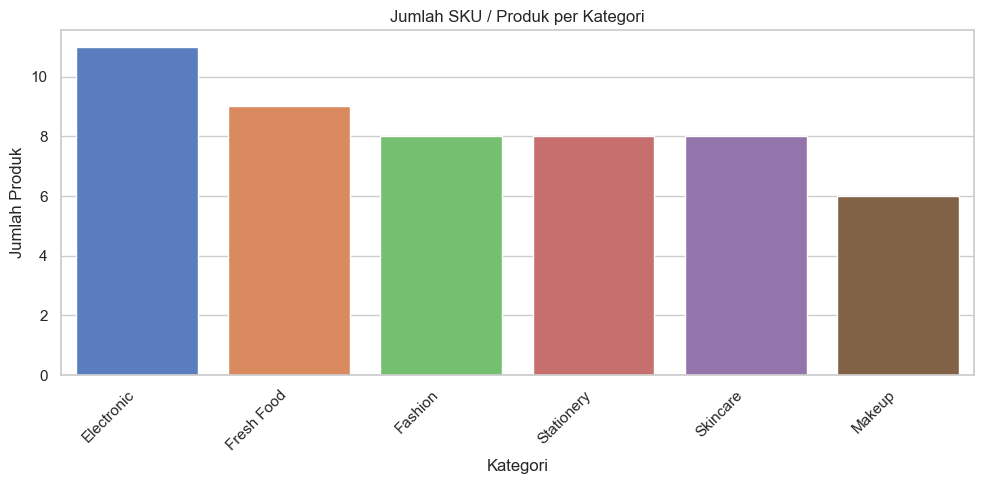

In [109]:
# Distribusi produk per kategori
if products is not None:
    plt.figure(figsize=(10,5))
    cat_counts = products["category"].fillna("UNSPECIFIED").value_counts()
    sns.barplot(x=cat_counts.index, y=cat_counts.values, palette="muted")
    plt.xticks(rotation=45, ha="right")
    plt.title("Jumlah SKU / Produk per Kategori")
    plt.ylabel("Jumlah Produk")
    plt.xlabel("Kategori")
    plt.tight_layout()
    plt.show()
else:
    print("products dataset tidak tersedia.")

C:\Users\tika\AppData\Local\Temp\ipykernel_6280\3294814101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp_wh, x="name", y="current_stock", palette="viridis")


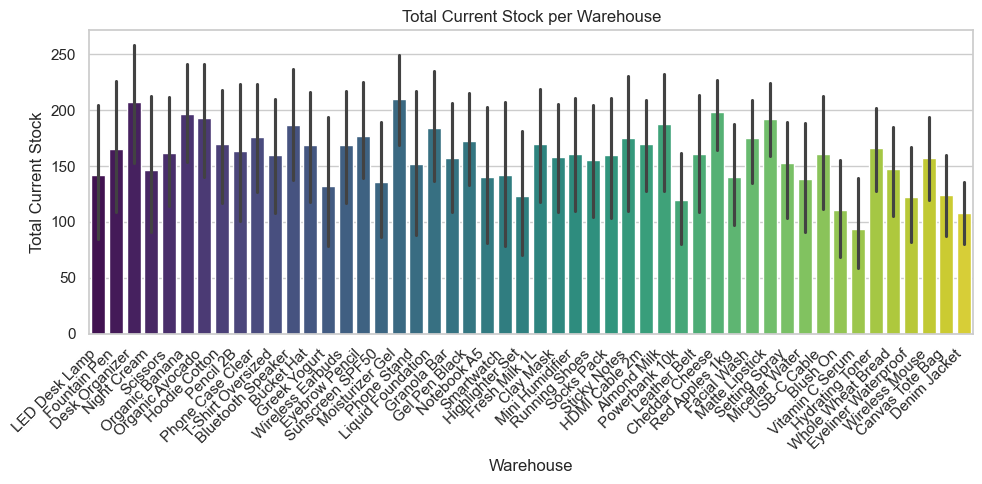

In [110]:
# Total current_stock per warehouse (nama gudang bila tersedia)
if inv_enriched is not None:
    grp_wh = inv_enriched.groupby(["warehouse_id", "name"])["current_stock"].sum().reset_index()
    grp_wh = grp_wh.sort_values("current_stock", ascending=False)
    plt.figure(figsize=(10,5))
    sns.barplot(data=grp_wh, x="name", y="current_stock", palette="viridis")
    plt.xticks(rotation=45, ha="right")
    plt.title("Total Current Stock per Warehouse")
    plt.ylabel("Total Current Stock")
    plt.xlabel("Warehouse")
    plt.tight_layout()
    plt.show()
else:
    print("inv_enriched tidak tersedia.")

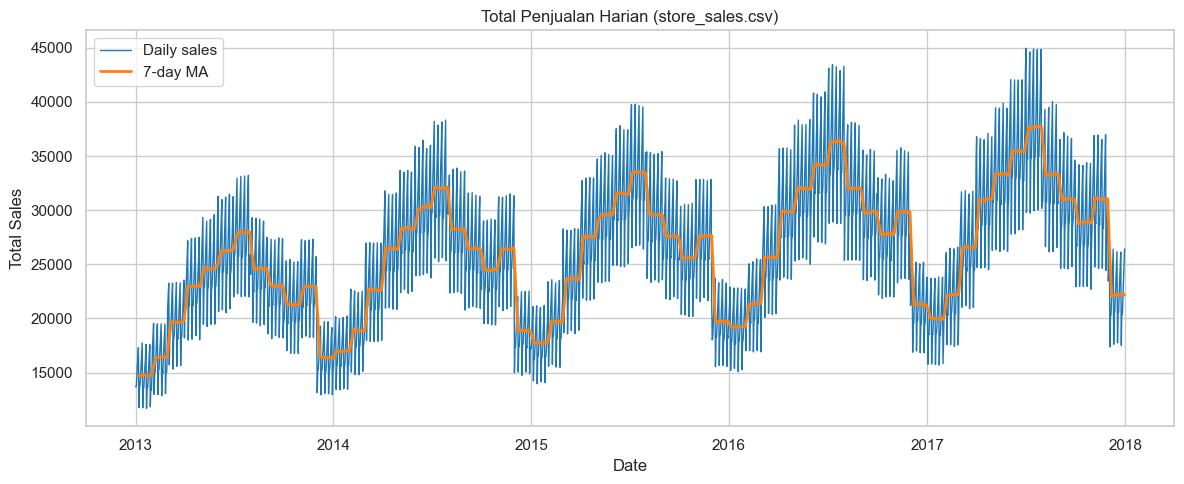

In [111]:
# Aggregate total sales per date (store_sales)
if store_sales is not None:
    df = store_sales.copy()
    # pastikan kolom date ter-parse
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    daily = df.groupby("date")["sales"].sum().sort_index()
    plt.figure(figsize=(12,5))
    plt.plot(daily.index, daily.values, color="tab:blue", linewidth=1, label="Daily sales")
    plt.plot(daily.index, daily.rolling(7).mean(), color="tab:orange", linewidth=2, label="7-day MA")
    plt.title("Total Penjualan Harian (store_sales.csv)")
    plt.xlabel("Date")
    plt.ylabel("Total Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("store_sales tidak tersedia.")

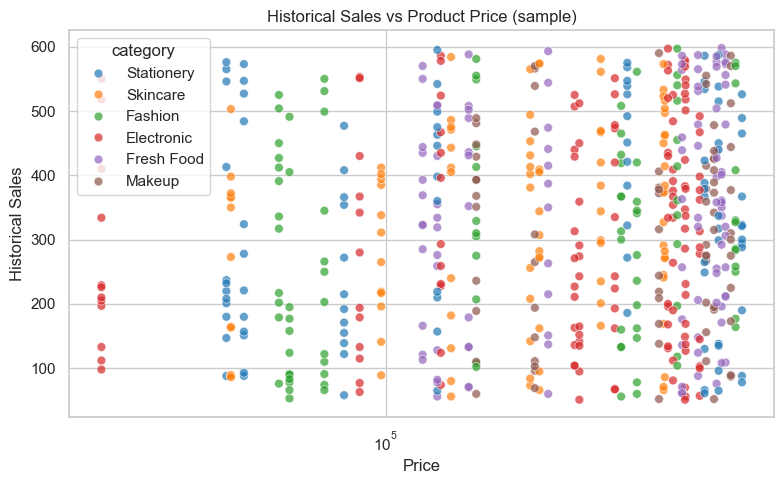

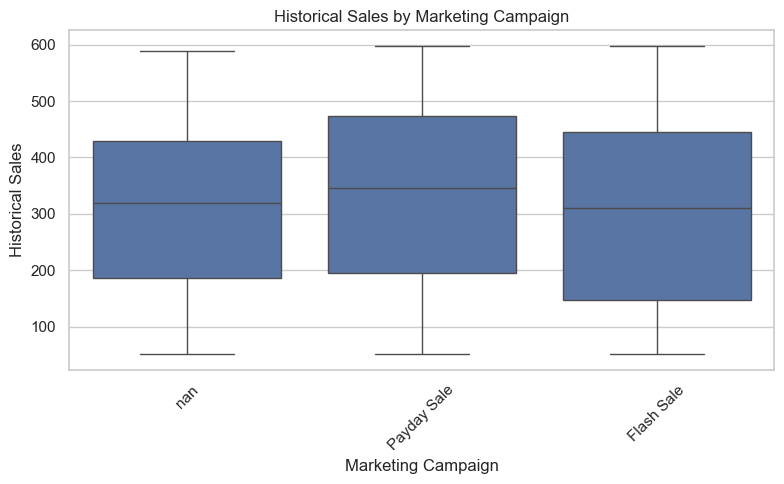

In [112]:
# historical_sales vs price (sales_data merged with products)
if sales_enriched is not None:
    df = sales_enriched.copy()
    # drop NA historical_sales
    df = df[df["historical_sales"].notna()]
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df.sample(min(len(df), 2000)), x="price", y="historical_sales", hue="category", palette="tab10", alpha=0.7, s=40)
    plt.title("Historical Sales vs Product Price (sample)")
    plt.xlabel("Price")
    plt.ylabel("Historical Sales")
    plt.xscale("log")  # price often skewed
    plt.tight_layout()
    plt.show()

    # Effect of marketing campaign (if column exists)
    if "marketing_campaign" in df.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=df["marketing_campaign"].astype(str), y="historical_sales", data=df)
        plt.title("Historical Sales by Marketing Campaign")
        plt.xlabel("Marketing Campaign")
        plt.ylabel("Historical Sales")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("sales_enriched tidak tersedia.")

In [113]:
# Missing value summary and cardinality checks
def quick_missing(df):
    if df is None: return None
    miss = df.isna().sum().sort_values(ascending=False)
    pct = (df.isna().mean()*100).sort_values(ascending=False)
    return pd.concat([miss, pct], axis=1, keys=["missing_count","missing_pct"])

for name, df in [("inventory", inventory), ("products", products), ("warehouses", warehouses), ("store_sales", store_sales), ("sales_data", sales_data)]:
    print(f"\n--- {name} ---")
    if df is None:
        print("Not available")
        continue
    display(quick_missing(df))
    display(df.nunique().sort_values(ascending=False).head(10))


--- inventory ---


,missing_count,missing_pct
expiry_date,360,72.0
id,0,0.0
product_id,0,0.0
warehouse_id,0,0.0
current_stock,0,0.0


id               500
current_stock    230
expiry_date      131
product_id        50
warehouse_id      10
dtype: int64


--- products ---


,missing_count,missing_pct
id,0,0.0
sku,0,0.0
name,0,0.0
category,0,0.0
price,0,0.0
weight,0,0.0


...

,missing_count,missing_pct
date,0,0.0
store,0,0.0
item,0,0.0
sales,0,0.0


date     1826
sales     213
item       50
store      10
dtype: int64


--- sales_data ---


,missing_count,missing_pct
marketing_campaign,200,33.333333
id,0,0.000000
product_id,0,0.000000
quarter,0,0.000000
historical_sales,0,0.000000


id                    600
historical_sales      354
product_id             50
quarter                 4
marketing_campaign      2
dtype: int64

In [114]:
# Save cleaned copies (non-destructive) into artifacts/ (optional)
OUT = ROOT / "artifacts"
OUT.mkdir(exist_ok=True)
if inventory is not None:
    inventory.drop(columns=[c for c in inventory.columns if "predict" in c.lower() or "project" in c.lower()], errors="ignore").to_csv(OUT / "inventory_clean.csv", index=False)
if sales_data is not None:
    sales_data.drop(columns=[c for c in sales_data.columns if "predict" in c.lower() or "project" in c.lower()], errors="ignore").to_csv(OUT / "sales_data_clean.csv", index=False)
print("Cleaned CSVs (no predictions) saved to", OUT)

Cleaned CSVs (no predictions) saved to c:\Users\tika\Downloads\FlowStock-AI\artifacts
